# Normal vs. Student's t: explore the tails

How does estimating a population standard deviation change the distribution used for inference?
Compare the **standard normal** $Z\sim N(0,1)$ with the **standard Student's t** $T_\nu$.
The degrees of freedom $\nu$ (written `df` in Python) control the shape of the t distribution.

By the end, you should be able to:

- Describe how changing degrees of freedom changes the t distribution.
- Distinguish the **height of a density curve** from **probability in a tail**.
- Use a positive cutoff to compare one-sided and two-sided tail probabilities.

This is an interactive companion to [the static comparison](Code-Example-008.1-t-distribution-vs.-normal-distribution.ipynb).

## 1. What does “heavier tails” mean?

For every **finite** $\nu>0$ and every **positive** cutoff $c$,

$$P(|T_\nu|>c)>P(|Z|>c),\qquad P(T_\nu>c)>P(Z>c).$$

By symmetry, the corresponding left-tail comparison beyond $-c$ also holds.
At $c=0$, the two-sided probabilities both equal 1, and the right-tail probabilities both equal 0.5.
As $\nu\to\infty$, the t distribution approaches the standard normal.

**Density is different from probability.** A density curve's height is not a tail probability;
tail probability is an area under the curve. Near zero, the normal density is higher.
Far enough from zero, the t density is higher. The curves cross, so “the normal curve is always lower” would be incorrect.

Both distributions here have **location 0 and scale 1**. They do not have the same variance:
the standard t variance is $\nu/(\nu-2)$ when $\nu>2$. It is not finite for $\nu\leq2$;
at $\nu=1$, even the mean is undefined, although the distribution remains symmetric about zero.
The tail ordering above refers to these standard distributions, not to arbitrary choices of normal and t scales.

## 2. Run the notebook

Open this notebook in JupyterLab or Jupyter Notebook with a Python 3 kernel, then choose **Run All**.
The saved example below is visible in a static notebook preview. **Live controls require a running kernel and widget support.**

If a dependency is missing, uncomment and run the installation line below, then restart the kernel and run all cells.
The notebook uses NumPy, SciPy, Matplotlib, and ipywidgets; it needs no dataset or network connection after setup.

In [ ]:
# Run only if packages are missing, then restart the kernel.
# %pip install numpy scipy matplotlib ipywidgets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

## 3. Calculate and draw the comparison

SciPy's survival function `sf(c)` computes $P(X>c)$ directly.
For these symmetric distributions, the two-sided probability is `2 * sf(c)`.
Using `sf` avoids the loss of precision that can occur when subtracting a CDF close to 1.

The left panel shows density and shades the selected tail region. The right panel shows
tail probabilities over many cutoffs on a **logarithmic** vertical axis, so small probabilities stay visible.
The numerical summary includes the entire tail out to infinity, including any area beyond the plot's edges.

In [2]:
NORMAL_COLOR = "#0072B2"
T_COLOR = "#D55E00"


def tail_probabilities(df, cutoff, tails="Two-sided"):
    """Return full normal and standard-t tail areas beyond a nonnegative cutoff."""
    if not np.isfinite(df) or df <= 0:
        raise ValueError("df must be finite and positive.")
    cutoff = np.asarray(cutoff, dtype=float)
    if np.any(~np.isfinite(cutoff)) or np.any(cutoff < 0):
        raise ValueError("cutoff must be finite and nonnegative.")
    if tails not in ("Two-sided", "Right tail"):
        raise ValueError("tails must be 'Two-sided' or 'Right tail'.")
    factor = 2 if tails == "Two-sided" else 1
    return factor * norm.sf(cutoff), factor * t.sf(cutoff, df)


def plot_comparison(df=5, cutoff=2.0, tails="Two-sided", log_density=False):
    """Draw both panels and return the figure and a plain-text numerical summary."""
    normal_p, t_p = tail_probabilities(df, cutoff, tails)
    if np.ndim(cutoff) != 0 or not 0 <= cutoff <= 5:
        raise ValueError("For this plot, cutoff must be a single number from 0 to 5.")
    x = np.unique(np.r_[np.linspace(-6, 6, 1601), -cutoff, cutoff])
    normal_pdf, t_pdf = norm.pdf(x), t.pdf(x, df)
    cutoffs = np.linspace(0, 5, 501)
    normal_tail, student_tail = tail_probabilities(df, cutoffs, tails)
    selected = np.abs(x) >= cutoff if tails == "Two-sided" else x >= cutoff
    probability_label = "P(|X| > c)" if tails == "Two-sided" else "P(X > c)"

    with plt.rc_context({"font.size": 11, "axes.titlesize": 13,
                         "axes.spines.top": False, "axes.spines.right": False}):
        fig, (density_ax, tail_ax) = plt.subplots(1, 2, figsize=(12, 4.6),
                                                constrained_layout=True)
        # Use both color and line style to distinguish the distributions.
        density_ax.plot(x, normal_pdf, color=NORMAL_COLOR, lw=2.5,
                        label="Normal N(0, 1)")
        density_ax.plot(x, t_pdf, color=T_COLOR, ls="--", lw=2.5,
                        label=f"Student's t (df = {df:g})")
        # Shading on a log-density axis is visual emphasis, not a probability area.
        baseline = 1e-9 if log_density else 0
        density_ax.fill_between(x, baseline, t_pdf, where=selected,
                                color=T_COLOR, alpha=0.14, hatch="///")
        density_ax.fill_between(x, baseline, normal_pdf, where=selected,
                                color=NORMAL_COLOR, alpha=0.22)
        density_ax.axvline(cutoff, color="0.35", ls=":", lw=1.4)
        if tails == "Two-sided" and cutoff > 0:
            density_ax.axvline(-cutoff, color="0.35", ls=":", lw=1.4)
        density_ax.set(xlim=(-6, 6), xlabel="Value x (location 0, scale 1)",
                       ylabel="Probability density", title="Shape and selected tails")
        if log_density:
            density_ax.set_yscale("log")
            density_ax.set_ylim(1e-9, 0.6)
            density_ax.set_ylabel("Probability density (log scale)")
        else:
            density_ax.set_ylim(0, 0.44)
        density_ax.legend(loc="lower center" if log_density else "upper right", fontsize=10)

        tail_ax.plot(cutoffs, normal_tail, color=NORMAL_COLOR, lw=2.5,
                     label="Normal N(0, 1)")
        tail_ax.plot(cutoffs, student_tail, color=T_COLOR, ls="--", lw=2.5,
                     label=f"Student's t (df = {df:g})")
        tail_ax.axvline(cutoff, color="0.35", ls=":", lw=1.4)
        tail_ax.scatter([cutoff], [normal_p], color=NORMAL_COLOR, marker="o", zorder=5)
        tail_ax.scatter([cutoff], [t_p], color=T_COLOR, marker="s", zorder=5)
        tail_ax.set_yscale("log")
        tail_ax.set(xlim=(-0.1, 5.1), ylim=(1e-7, 1.3), xlabel="Cutoff c",
                    ylabel=probability_label + " (log scale)",
                    title="Full tail probability beyond each cutoff")
        tail_ax.legend(loc="lower left", fontsize=10)
        for ax in (density_ax, tail_ax):
            ax.grid(True, which="major", alpha=0.2)

    relation = "Equal at cutoff 0." if cutoff == 0 else "The t tail probability is larger."
    summary = (
        f"df = {df:g}; cutoff c = {cutoff:g}; {tails.lower()}\n"
        f"{probability_label}:  Normal = {normal_p:.8g} ({normal_p:.6%})\n"
        f"{'':<{len(probability_label) + 3}}Student's t = {t_p:.8g} ({t_p:.6%})\n"
        f"t minus normal = {t_p - normal_p:.8g} "
        f"({100 * (t_p - normal_p):.6g} percentage points)\n"
        f"t / normal = {t_p / normal_p:.6g} times.  {relation}\n"
        "Probabilities include the full tails beyond the visible x range."
    )
    if log_density:
        summary += "\nLog-density view: shaded screen area is NOT probability; use the numbers."
    return fig, summary

### Saved starting example

With **df = 5** and **cutoff = 2**, compare the shaded tails and read the numerical summary.
Solid blue lines and circular markers denote the normal distribution; dashed orange lines and square markers denote t.

df = 5; cutoff c = 2; two-sided
P(|X| > c):  Normal = 0.045500264 (4.550026%)
             Student's t = 0.10193948 (10.193948%)
t minus normal = 0.056439215 (5.64392 percentage points)
t / normal = 2.24042 times.  The t tail probability is larger.
Probabilities include the full tails beyond the visible x range.


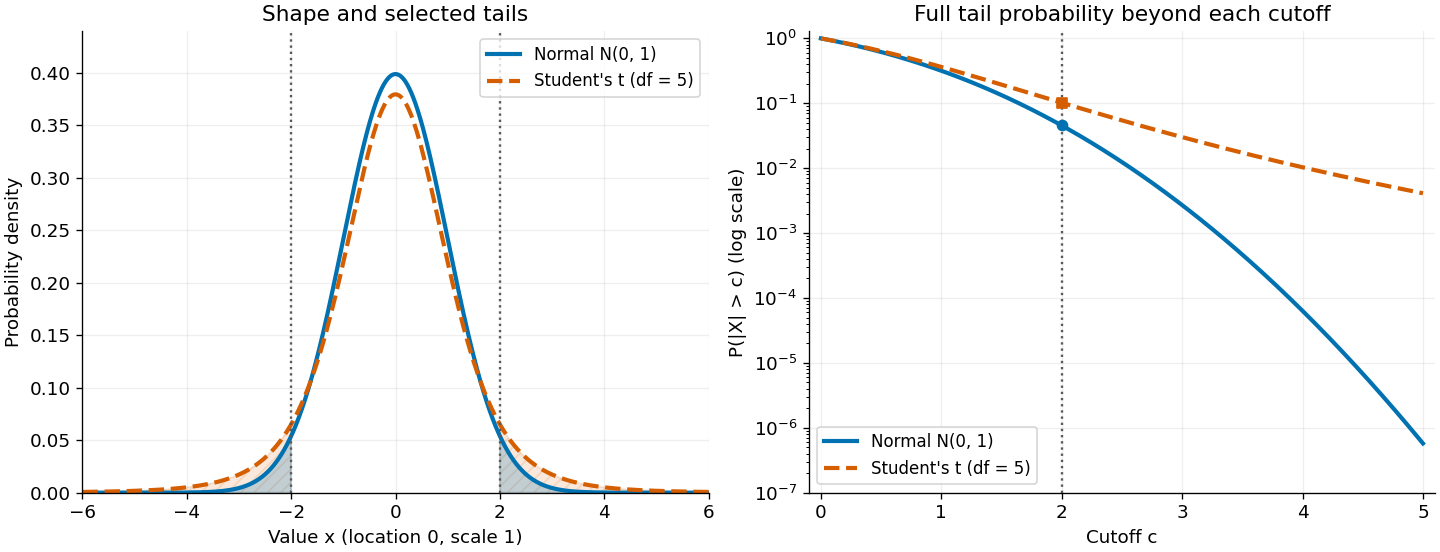

In [3]:
fig, summary = plot_comparison(df=5, cutoff=2.0)
print(summary)
plt.show()
plt.close(fig)

## 4. Change the controls

- **Degrees of freedom:** use 1–200. Small values make the heavier tails easier to see; large values approach the normal.
- **Cutoff c:** select 0–5. The dotted lines and markers follow this value.
- **Tail region:** compare both tails or only the right tail.
- **Log density:** reveal small density values. On this scale, shaded screen area is not a probability.

Move a slider or focus it and use the arrow keys; you can also edit its numerical readout.
Plots update when you release a slider. The normal distribution stays fixed as you change df.
The text summary provides the probabilities without relying on color or visual area.

If controls appear as plain text or do not respond, use a Jupyter environment with ipywidgets support and a live kernel.
You can also edit the numbers in the saved-example cell and rerun it without widgets.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Interactive controls require ipywidgets and IPython. "
          "Install ipywidgets, restart the kernel, and run all cells. "
          "Meanwhile, edit df and cutoff in the saved-example cell.")
else:
    df_slider = widgets.IntSlider(
        value=5, min=1, max=200, step=1, description="Degrees of freedom",
        continuous_update=False, style={"description_width": "150px"},
        layout=widgets.Layout(width="95%", max_width="650px"))
    cutoff_slider = widgets.FloatSlider(
        value=2.0, min=0.0, max=5.0, step=0.25, description="Cutoff c",
        readout_format=".2f", continuous_update=False,
        style={"description_width": "150px"},
        layout=widgets.Layout(width="95%", max_width="650px"))
    tails_control = widgets.Dropdown(
        options=["Two-sided", "Right tail"], value="Two-sided",
        description="Tail region", style={"description_width": "150px"},
        layout=widgets.Layout(width="95%", max_width="400px"))
    log_control = widgets.Checkbox(value=False, description="Log density",
                                  indent=False)

    def update_plot(df, cutoff, tails, log_density):
        figure, text_summary = plot_comparison(df, cutoff, tails, log_density)
        print(text_summary)
        plt.show()
        plt.close(figure)

    output = widgets.interactive_output(update_plot, {
        "df": df_slider, "cutoff": cutoff_slider,
        "tails": tails_control, "log_density": log_control})
    display(widgets.VBox([df_slider, cutoff_slider, tails_control, log_control]), output)

## 5. Explore, record, explain

1. Set **two-sided**, **cutoff = 2.5**, and vary df through **1, 3, 10, 40, 200**.
   Record both tail probabilities and their ratio. Describe the pattern as df increases.
2. Fix **df = 7**. Compare cutoffs **1, 2, 3, 4**. Record the absolute difference and the ratio.
   Do these two measures of “difference” tell the same story? Explain using your results.
3. Fix **df = 12** and **cutoff = 1.5**. Switch between the right tail and both tails.
   What changes in the probabilities, difference, and ratio? Use symmetry to explain.
4. Set **cutoff = 0**, then move it to **0.25**. How does this boundary case affect the word “always”?
5. With **df = 3**, compare the density heights near zero and far from zero.
   Explain why a statement about tail probability is different from a statement about every density height.

## 6. Connection to a one-sample t test

For an independent random sample of size $n$ from a normal population, replacing the unknown
population standard deviation with the sample standard deviation leads to

$$T=\frac{\bar X-\mu_0}{S/\sqrt n}\sim t_{n-1}\quad\text{under the null hypothesis}.$$

The t distribution accounts for uncertainty from estimating that standard deviation.
Here $\nu=n-1$; other procedures can use different degrees of freedom.
When the population standard deviation is known, the corresponding standardized mean has a standard normal distribution under these assumptions.
For the **same nonzero observed statistic**, a finite-df t reference gives a larger two-sided p-value than a standard normal reference.
Actual z and t statistics computed from data can differ, so this statement keeps the statistic's value fixed.

Choose two sample sizes of your own, translate each into df, and compare the tail probabilities at a fixed cutoff of your choice.

## References

- [NIST: Student's t distribution](https://www.itl.nist.gov/div898/handbook/eda/section3/eda3664.htm) — distribution shape, degrees of freedom, and moments.
- [SciPy: scipy.stats.t](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html) — `pdf`, `sf`, and standard t parameters.
- [SciPy: scipy.stats.norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) — standard normal calculations.
- [Jupyter widgets: Using interact](https://ipywidgets.readthedocs.io/en/stable/examples/Using%20Interact.html) — interactive controls and `interactive_output`.